In [2]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import torch
import geopandas as gpd
import pandas as pd
import os
from pathlib import Path
import sys
def configure_proj_data():
    candidates = [
        Path(sys.prefix) / "Library" / "share" / "proj",
        Path(sys.prefix) / "Lib" / "site-packages" / "pyproj" / "proj_dir" / "share" / "proj",
        Path(os.environ.get("CONDA_PREFIX", "")) / "Library" / "share" / "proj",
        Path.home() / ".conda" / "envs" / "3s" / "Library" / "share" / "proj",
    ]

    for candidate in candidates:
        if (candidate / "proj.db").exists():
            os.environ["PROJ_LIB"] = str(candidate)
            os.environ["PROJ_DATA"] = str(candidate)

            import pyproj
            pyproj.datadir.set_data_dir(str(candidate))

            print("PROJ database:", candidate)
            return

    print("WARNING: proj.db not found")

configure_proj_data()

c:/Users/user\.conda\envs\gis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:/Users/user\.conda\envs\gis\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


PROJ database: c:/Users/user\.conda\envs\gis\Library\share\proj


In [3]:
dem_file = gpd.read_file(r"GIS_features\dem_features_15msa.csv")
print(dem_file)
ndvi_file = gpd.read_file(r"GIS_features\ndvi_features_15msa.csv")
print(ndvi_file)
nlcd_file = gpd.read_file(r"GIS_features\nlcd_features_15msa.csv")
print(nlcd_file)
poi_file = gpd.read_file(r"GIS_features\poi_features_15msa.csv")
print(poi_file)
pop_file = gpd.read_file(r"GIS_features\pop_features_15msa.csv")
print(pop_file)
eco_file = gpd.read_file(r"GIS_features\socioeconomic_features_15msa.csv")
print(eco_file)
tcc_file = gpd.read_file(r"GIS_features\tcc_features_15msa.csv")
print(tcc_file)
water_file = gpd.read_file(r"GIS_features\water_dist_features_15msa.csv")
print(water_file)

                  cb_2020_3           elev_mean          slope_mean
0      1400000US36001000100  10.151410899072358   2.014119249106916
1      1400000US36001000201   43.42743607961705   4.457643650667111
2      1400000US36001000202  45.000347536043016   6.468748682853374
3      1400000US36001000301   73.22879264271107  2.1908035614383885
4      1400000US36001000302   73.74633382416408   3.350081471799008
...                     ...                 ...                 ...
11153  1400000US40109980005   376.1320405135481  2.1629909722167198
11154  1400000US40109980006   377.6609643449793   1.502903346982855
11155  1400000US40109980007   365.4198301238134  1.3007315854660209
11156  1400000US40109980008   376.6921134917667  2.1088399586182365
11157  1400000US40109980009  364.94981815733223  0.2566569761528144

[11158 rows x 3 columns]
                  cb_2020_3            ndvi_mean
0      1400000US36001000100  0.27908059877692826
1      1400000US36001000201  0.37287658874089824
2      1400

In [4]:
gdf = dem_file.merge(ndvi_file,
                on="cb_2020_3",
                how="inner")
print(gdf)
gdf = gdf.merge(nlcd_file,
                on="cb_2020_3",
                how="inner")
print(gdf)
gdf = gdf.merge(poi_file,
                on="cb_2020_3",
                how="inner")
print(gdf)
gdf = gdf.merge(pop_file,
                on="cb_2020_3",
                how="inner")
print(gdf)
gdf = gdf.merge(eco_file,
                on="cb_2020_3",
                how="inner")
print(gdf)
gdf = gdf.merge(tcc_file,
                on="cb_2020_3",
                how="inner")
print(gdf)
gdf = gdf.merge(water_file,
                on="cb_2020_3",
                how="inner")
print(gdf)

                  cb_2020_3           elev_mean          slope_mean  \
0      1400000US36001000100  10.151410899072358   2.014119249106916   
1      1400000US36001000201   43.42743607961705   4.457643650667111   
2      1400000US36001000202  45.000347536043016   6.468748682853374   
3      1400000US36001000301   73.22879264271107  2.1908035614383885   
4      1400000US36001000302   73.74633382416408   3.350081471799008   
...                     ...                 ...                 ...   
11153  1400000US40109980005   376.1320405135481  2.1629909722167198   
11154  1400000US40109980006   377.6609643449793   1.502903346982855   
11155  1400000US40109980007   365.4198301238134  1.3007315854660209   
11156  1400000US40109980008   376.6921134917667  2.1088399586182365   
11157  1400000US40109980009  364.94981815733223  0.2566569761528144   

                 ndvi_mean  
0      0.27908059877692826  
1      0.37287658874089824  
2       0.3770448756665421  
3       0.4143471231738868  
4 

In [5]:
print(gdf.columns)

Index(['cb_2020_3', 'elev_mean', 'slope_mean', 'ndvi_mean', 'water_pct',
       'developed_pct', 'barren_pct', 'forest_pct', 'shrub_pct',
       'grassland_pct', 'pasture_hay_pct', 'cultivated_crops_pct',
       'woody_wetlands_pct', 'herbaceous_wetlands_pct', 'impervious_mean',
       'poi_edu', 'poi_comm', 'poi_med', 'poi_trans', 'poi_pub', 'poi_food',
       'poi_finance', 'poi_total_all', 'poi_diversity', 'minor_ratio',
       'elderly_ratio', 'sex_ratio', 'fam_inc_lt10k', 'fam_inc_lt10k_moe',
       'fam_inc_10to15k', 'fam_inc_10to15k_moe', 'fam_inc_15to25k',
       'fam_inc_15to25k_moe', 'fam_inc_25to50k', 'fam_inc_25to50k_moe',
       'fam_inc_50kplus', 'fam_inc_50kplus_moe', 'median_family_income',
       'median_family_income_moe', 'per_capita_income',
       'per_capita_income_moe', 'persons_below_poverty',
       'persons_below_poverty_moe', 'tcc_mean', 'dist_water_m'],
      dtype='object')


In [8]:
import numpy as np
feature_cols = ['elev_mean', 'slope_mean', 'ndvi_mean', 'water_pct',
       'developed_pct', 'barren_pct', 'forest_pct',
       'grassland_pct', 'pasture_hay_pct', 'cultivated_crops_pct',
       'woody_wetlands_pct', 'herbaceous_wetlands_pct', 'impervious_mean',
       'poi_edu', 'poi_comm', 'poi_med', 'poi_trans', 'poi_pub', 'poi_food',
       'poi_finance', 'poi_total_all', 'poi_diversity', 'minor_ratio',
       'elderly_ratio', 'sex_ratio', 'fam_inc_lt10k', 'fam_inc_lt10k_moe',
       'fam_inc_10to15k', 'fam_inc_10to15k_moe', 'fam_inc_15to25k',
       'fam_inc_15to25k_moe', 'fam_inc_25to50k', 'fam_inc_25to50k_moe',
       'fam_inc_50kplus', 'fam_inc_50kplus_moe', 'median_family_income',
       'median_family_income_moe', 'per_capita_income',
       'per_capita_income_moe', 'persons_below_poverty',
       'persons_below_poverty_moe', 'tcc_mean', 'dist_water_m']
  
gdf_corr = gdf[feature_cols].copy()

for col in feature_cols:
    gdf_corr[col] = pd.to_numeric(
        gdf_corr[col],
        errors="coerce"
    )
gdf_corr = gdf_corr.dropna()
corr_matrix = gdf_corr.corr(method="pearson")
print(corr_matrix)

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = upper.stack()
high_corr = high_corr[abs(high_corr) > 0.6]

print("相关性绝对值 > 0.8 的变量：")
print(high_corr)

                           elev_mean  slope_mean  ndvi_mean  water_pct  \
elev_mean                   1.000000    0.361882   0.607742  -0.108627   
slope_mean                  0.361882    1.000000   0.472347  -0.004855   
ndvi_mean                   0.607742    0.472347   1.000000  -0.275204   
water_pct                  -0.108627   -0.004855  -0.275204   1.000000   
developed_pct              -0.297016   -0.427417  -0.496123  -0.337123   
barren_pct                  0.016420    0.039384   0.016469   0.099861   
forest_pct                  0.379666    0.621967   0.581697   0.022424   
grassland_pct               0.104892    0.117773   0.215801  -0.007072   
pasture_hay_pct             0.228484    0.016446   0.120994  -0.006683   
cultivated_crops_pct        0.206588    0.222572   0.419847  -0.000072   
woody_wetlands_pct         -0.005585   -0.004572   0.326096   0.032629   
herbaceous_wetlands_pct    -0.041803   -0.067303   0.005643   0.202804   
impervious_mean            -0.422591  

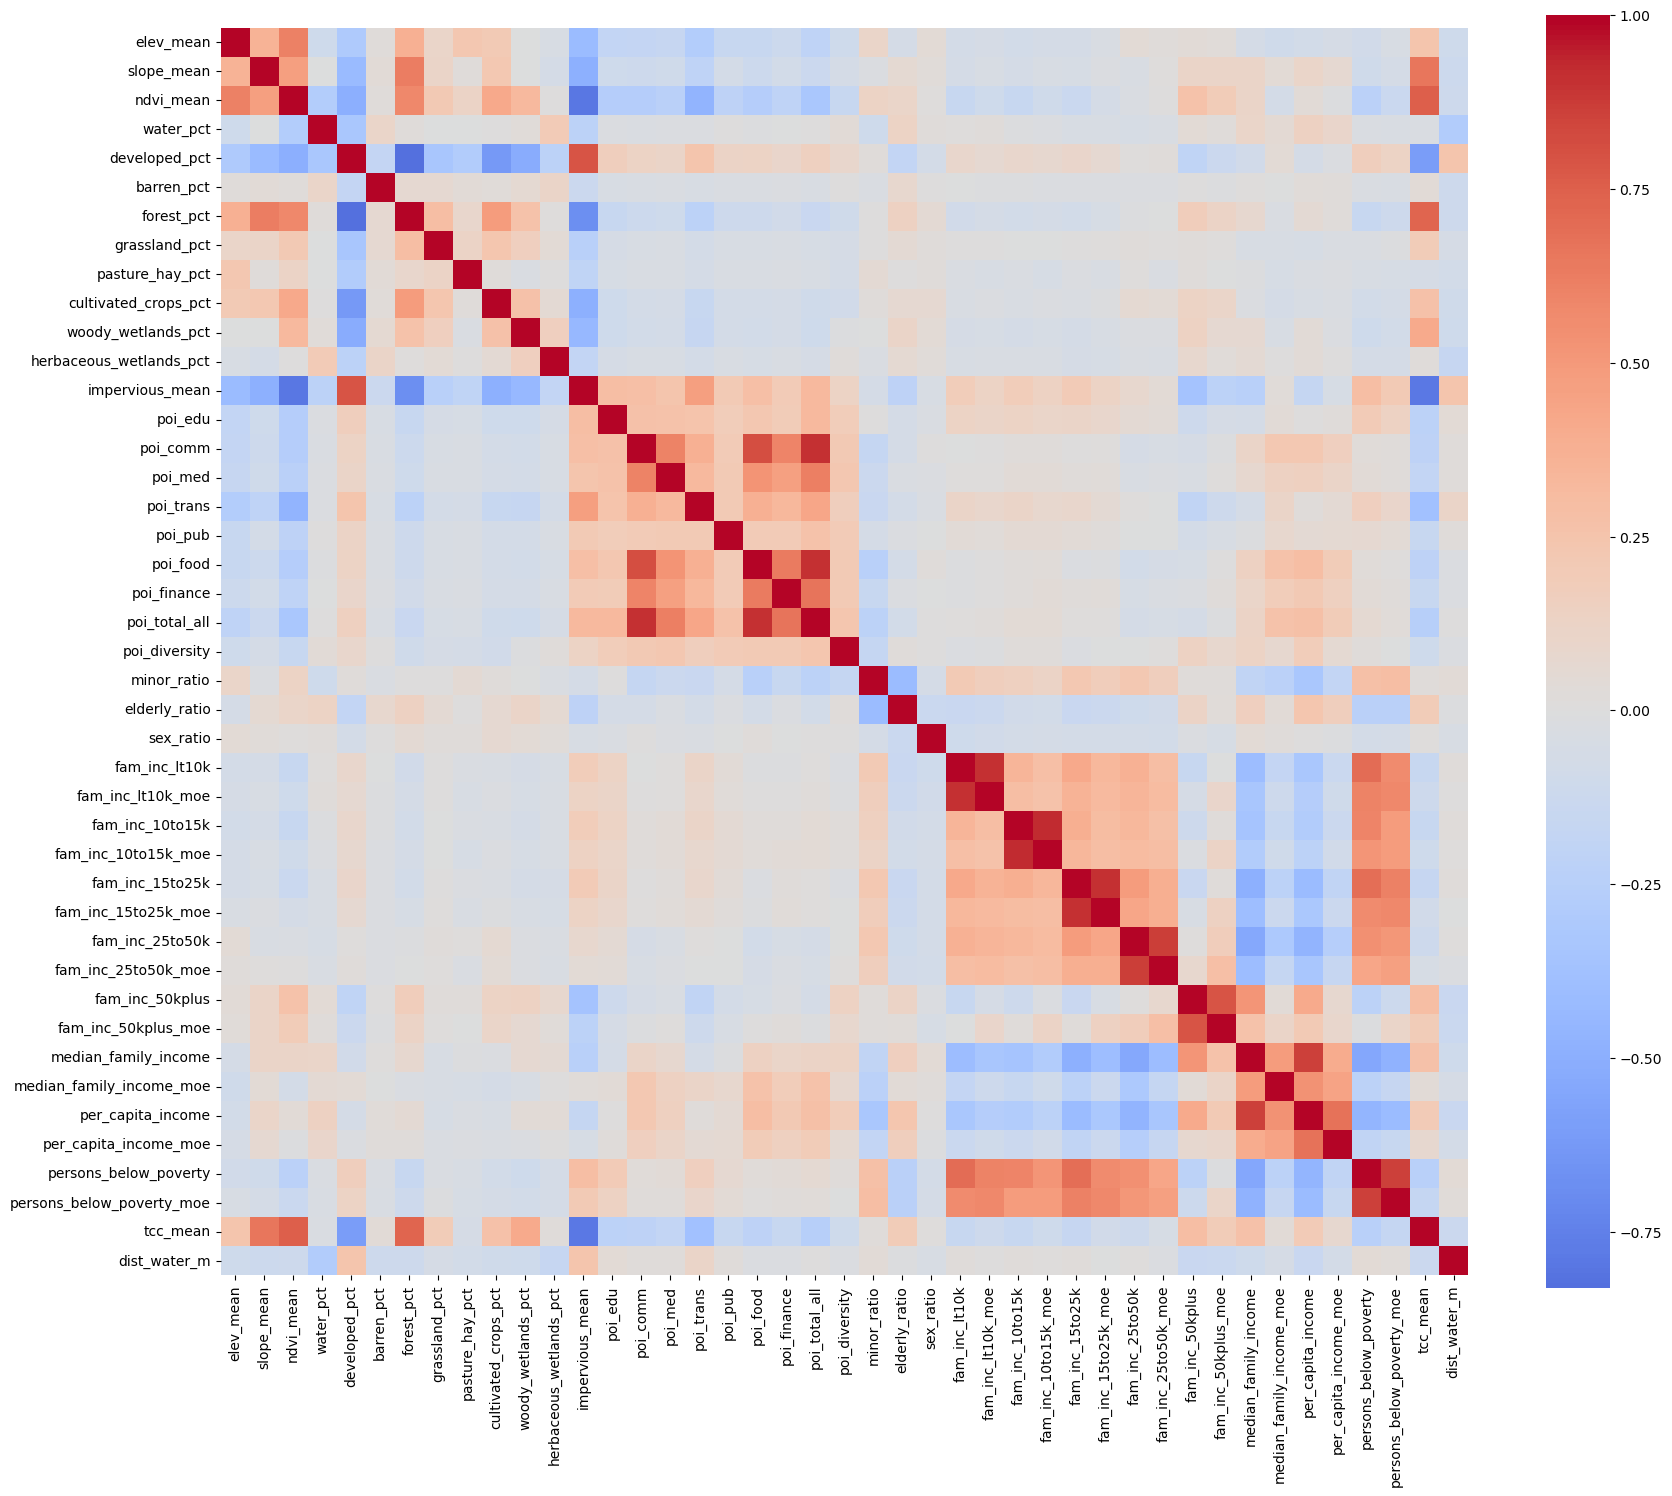

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,15))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.tight_layout()
plt.show()

In [10]:
feature_cols = ['elev_mean', 'slope_mean', 'ndvi_mean', 'water_pct',
       'developed_pct', 'barren_pct', 'forest_pct',
       'grassland_pct', 'pasture_hay_pct', 'cultivated_crops_pct',
       'woody_wetlands_pct', 'herbaceous_wetlands_pct',
       'poi_edu', 'poi_comm', 'poi_med', 'poi_trans', 'poi_pub', 'poi_food',
       'poi_finance', 'poi_diversity', 'minor_ratio',
       'elderly_ratio', 'sex_ratio', 'fam_inc_lt10k', 
       'fam_inc_10to15k', 'fam_inc_15to25k',
       'fam_inc_25to50k', 
       'fam_inc_50kplus',  'median_family_income',
       'persons_below_poverty', 'dist_water_m']
  
gdf_corr = gdf[feature_cols].copy()

for col in feature_cols:
    gdf_corr[col] = pd.to_numeric(
        gdf_corr[col],
        errors="coerce"
    )
gdf_corr = gdf_corr.dropna()
corr_matrix = gdf_corr.corr(method="pearson")
print(corr_matrix)


                         elev_mean  slope_mean  ndvi_mean  water_pct  \
elev_mean                 1.000000    0.360965   0.606489  -0.115630   
slope_mean                0.360965    1.000000   0.475871  -0.009886   
ndvi_mean                 0.606489    0.475871   1.000000  -0.287607   
water_pct                -0.115630   -0.009886  -0.287607   1.000000   
developed_pct            -0.292730   -0.424898  -0.484275  -0.340180   
barren_pct                0.016478    0.038731   0.017939   0.095959   
forest_pct                0.377412    0.621063   0.576667   0.017263   
grassland_pct             0.105255    0.116097   0.213093  -0.008377   
pasture_hay_pct           0.227422    0.015795   0.119766  -0.007572   
cultivated_crops_pct      0.207991    0.220330   0.415197  -0.003033   
woody_wetlands_pct       -0.003869   -0.003465   0.323783   0.027970   
herbaceous_wetlands_pct  -0.042234   -0.066750   0.007198   0.196129   
poi_edu                  -0.190561   -0.111534  -0.276466  -0.01

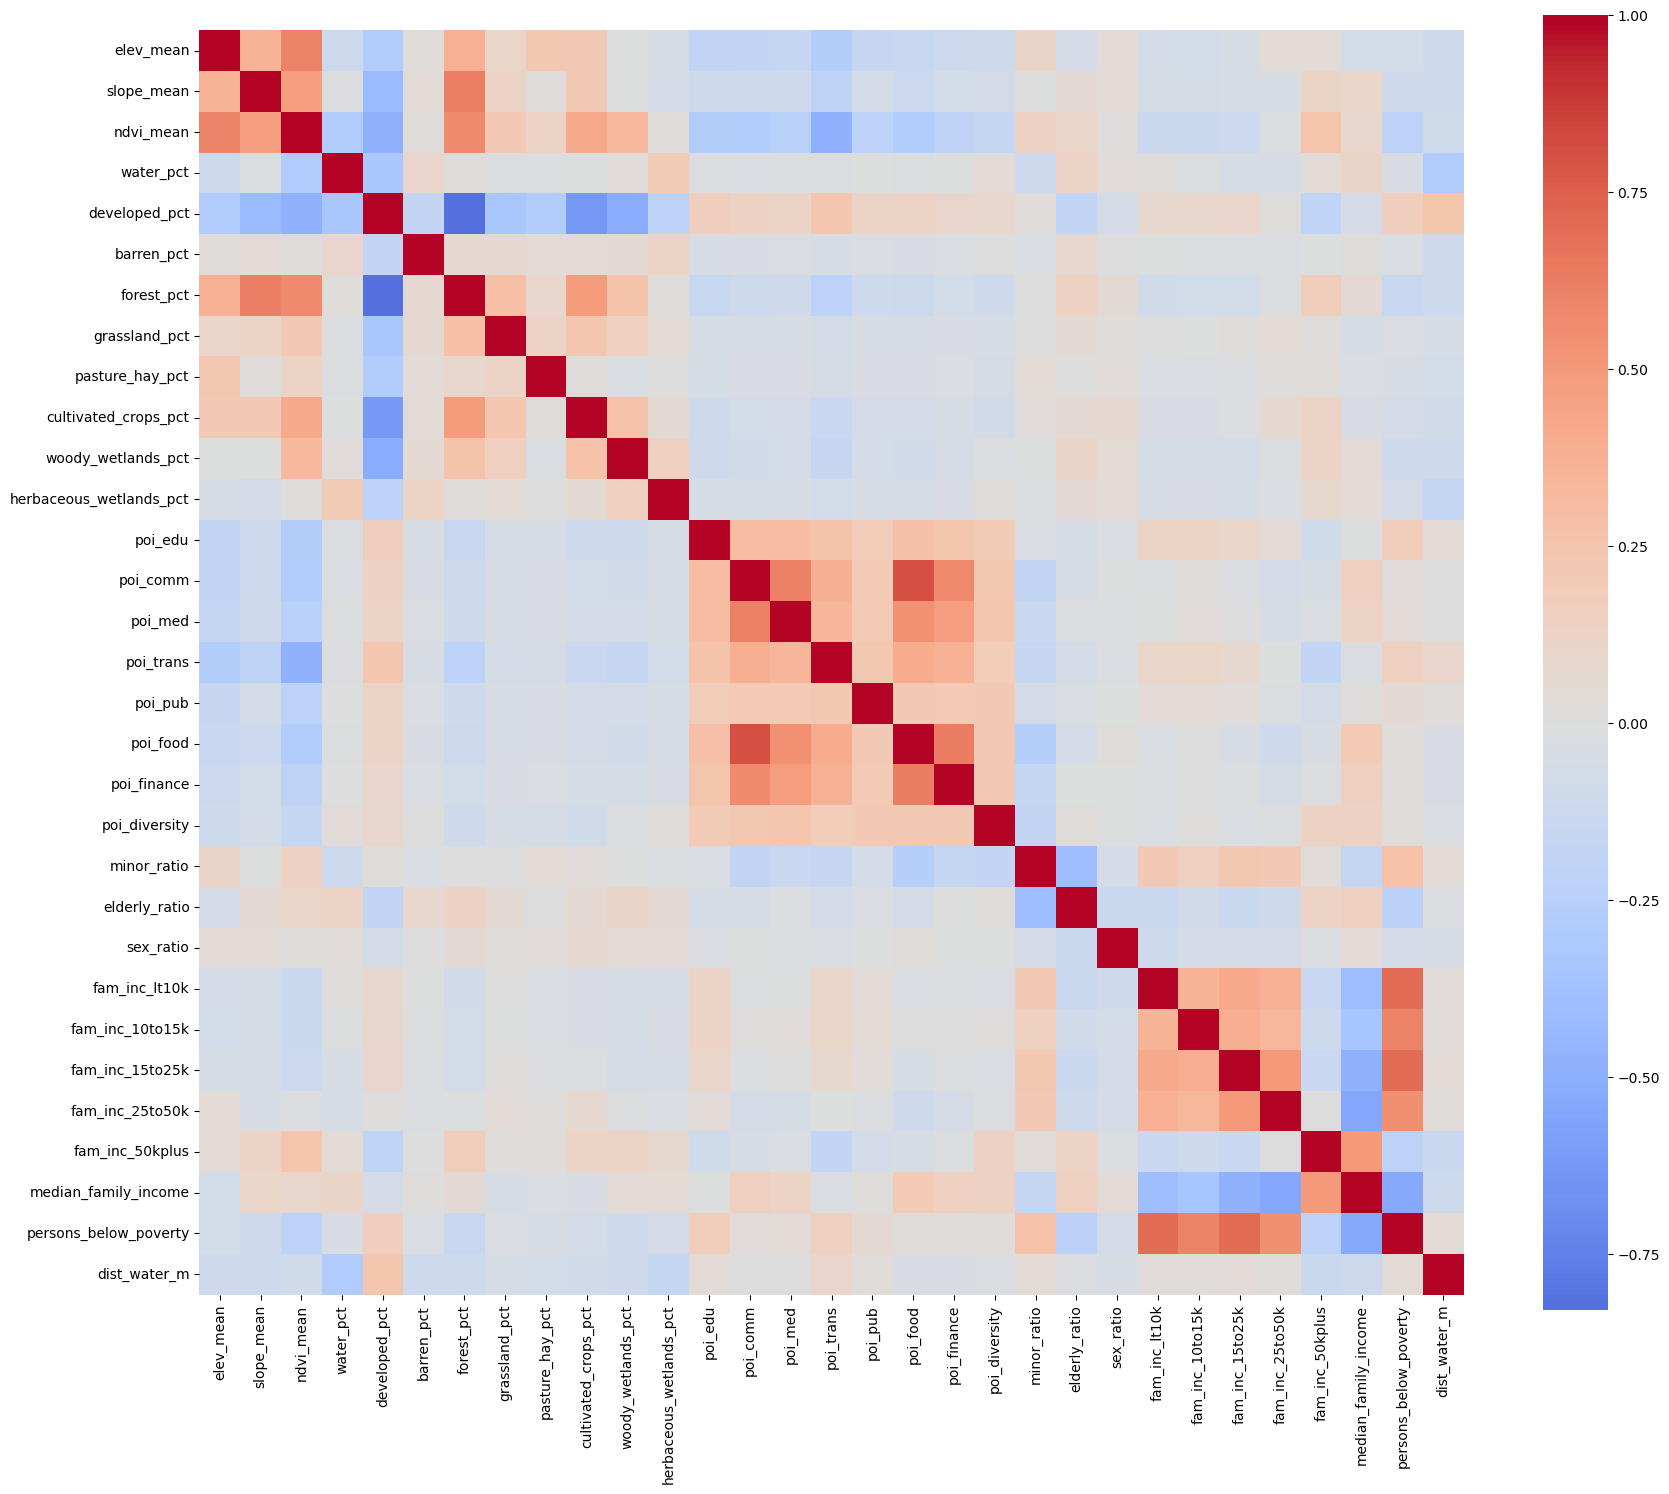

In [11]:
plt.figure(figsize=(18,15))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.tight_layout()
plt.show()